# Rainfall maps from CML data: IDW, GMZ, and line-aware interpolation

Five reconstructions of the same rain field, from the same links at the same
timestep, using four packages from the OpenSense ecosystem. Because the input
is fixed, the differences are the *methods*.

| | package | geometry |
|---|---|---|
| IDW | `pycomlink` | link **midpoint** |
| IDW | `pynncml` | link **midpoint** |
| **GMZ** | `pynncml` | link **line** — several points per link |
| IDW | `mergeplg` | link **line** |
| block kriging | `mergeplg` | link **line** |

The split that matters is midpoint versus line. A CML measures a path average
over kilometres; collapsing it to its midpoint throws that away. GMZ
(Goldshtein–Messer–Zinevich) and the `mergeplg` pair both keep it.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "core").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "projects/cml_retrieval/src"))

import numpy as np
import matplotlib.pyplot as plt

import rain_maps

## A note before GMZ runs

`pynncml` 0.3.7's GMZ has two defects in its bilinear interpolation, both in
`compute_rain_point_from_field`. `rain_maps.patch_pynncml_gmz()` fixes them in
memory; they belong upstream.

1. **The ceiling index is unclamped** — it reaches `len(grid)` whenever a link
   point lands on the edge of the bounding box built from the links
   themselves, so a full network raises `IndexError`.
2. **The ceiling-ceiling corner reads the wrong axis** —
   `cc = in_rain_map[:, j_ceiling, j_ceiling]` uses the *y* index twice where
   it should be `[i_ceiling, j_ceiling]`. This one does not raise. It silently
   samples the wrong grid cell for one of four bilinear corners, wherever
   `i_ceiling != j_ceiling`.

In [2]:
for fix in rain_maps.patch_pynncml_gmz():
    print("patched:", fix)

patched: clamped i_ceiling/j_ceiling to the grid
patched: cc corner now reads [i_ceiling, j_ceiling], was [j_ceiling, j_ceiling]


/Users/drorjac/PycharmProjects/FieldSense/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The data

OpenMRG, from the curated OpenSense subset. Rain rates are the *reference*
retrieval the subset ships, so this compares reconstruction rather than
retrieval choices.

In [3]:
cml = rain_maps.load_cml_rain(subset="8d")

R = np.asarray(cml.R)
print(f"timestep : {cml.attrs['time'][:16]} UTC")
print(f"links    : {cml.sizes['cml_id']}  ({int((R >= 0.1).sum())} reporting rain)")
print(f"rain     : {np.nanmin(R):.2f} .. {np.nanmax(R):.2f} mm/h")
print(f"lengths  : {float(cml.length_km.min()):.2f} .. {float(cml.length_km.max()):.1f} km")

  [skip]  openmrg_cml_8d.nc  (26.87 MB, already present)


  [skip]  openmrg_rad_8d.nc  (1.25 MB, already present)


  [skip]  openmrg_municp_gauge_8d.nc  (0.13 MB, already present)


  [skip]  openmrg_smhi_gauge_8d.nc  (0.02 MB, already present)


timestep : 2015-07-23T01:40 UTC
links    : 364  (288 reporting rain)
rain     : 0.00 .. 107.72 mm/h
lengths  : 0.14 .. 15.2 km


## Generating the maps

In [4]:
maps = {}
for name, fn in rain_maps.METHODS.items():
    maps[name] = fn(cml)
    g = maps[name]["grid"]
    print(f"{name:18s} {str(g.shape):11s} "
          f"{np.nanmin(g):6.2f} .. {np.nanmax(g):7.2f} mm/h   "
          f"{maps[name]['label']}")

pycomlink_idw      (130, 176)    0.00 ..   85.92 mm/h   pycomlink IDW (midpoint)


pynncml_idw        (56, 74)      0.00 ..   84.62 mm/h   pynncml IDW (midpoint)


pynncml_gmz        (56, 74)      0.00 ..   66.61 mm/h   pynncml GMZ (3 pts/link)


mergeplg_idw       (155, 120)    0.00 ..   72.85 mm/h   mergeplg IDW (line-aware)


mergeplg_kriging   (155, 120)   -0.51 ..   80.52 mm/h   mergeplg block kriging (line-aware)


## Side by side

Each on its own grid and projection — `pycomlink` works in lon/lat, the others
in UTM — so the panels are not pixel-aligned. The structure is what to
compare.

Text(0.5, 1.02, 'OpenMRG 2015-07-23T01:40 UTC — the same links, five reconstructions')

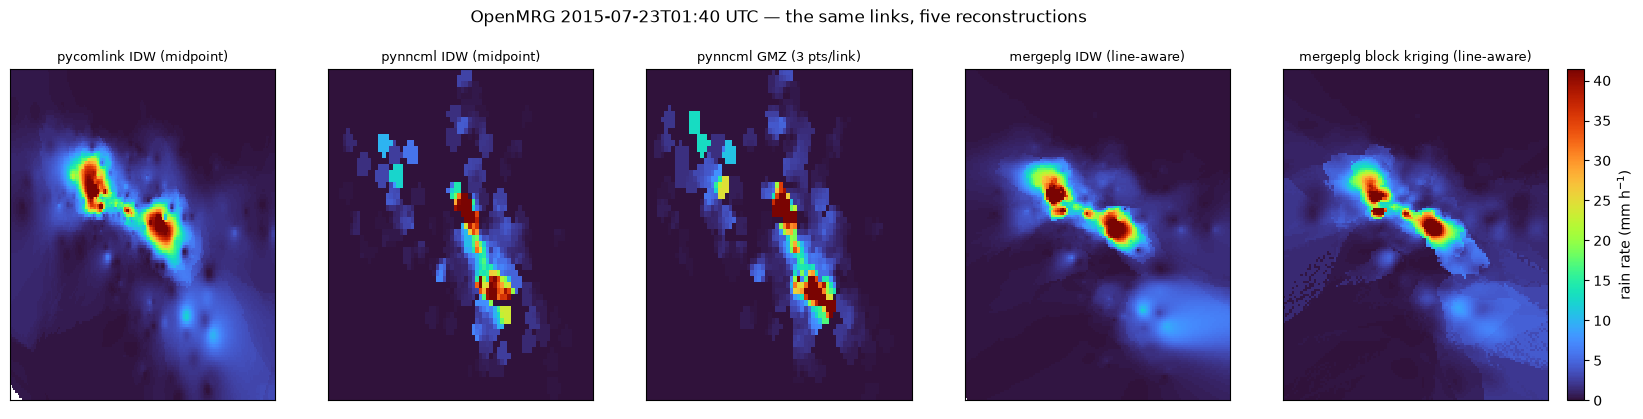

In [5]:
vmax = float(np.nanpercentile(
    np.concatenate([m["grid"].ravel() for m in maps.values()]), 99.5))

fig, axes = plt.subplots(1, len(maps), figsize=(4.1 * len(maps), 4.3))
for ax, (name, m) in zip(axes, maps.items()):
    g = m["grid"]
    extent = [np.min(m["x"]), np.max(m["x"]), np.min(m["y"]), np.max(m["y"])]
    im = ax.imshow(g, origin="lower", extent=extent, vmin=0, vmax=vmax,
                   cmap="turbo", aspect="auto", interpolation="nearest")
    ax.set_title(m["label"], fontsize=9.5)
    ax.set_xticks([])
    ax.set_yticks([])

cb = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.012)
cb.set_label("rain rate (mm h$^{-1}$)")
fig.suptitle(f"OpenMRG {cml.attrs['time'][:16]} UTC — the same links, "
             f"five reconstructions", y=1.02, fontsize=12.5)

## Midpoint versus line

Overlaying the link paths shows what the geometry buys. Midpoint methods place
all of a link's information at one point; line-aware methods spread it along
the path, which matters most for the long links.

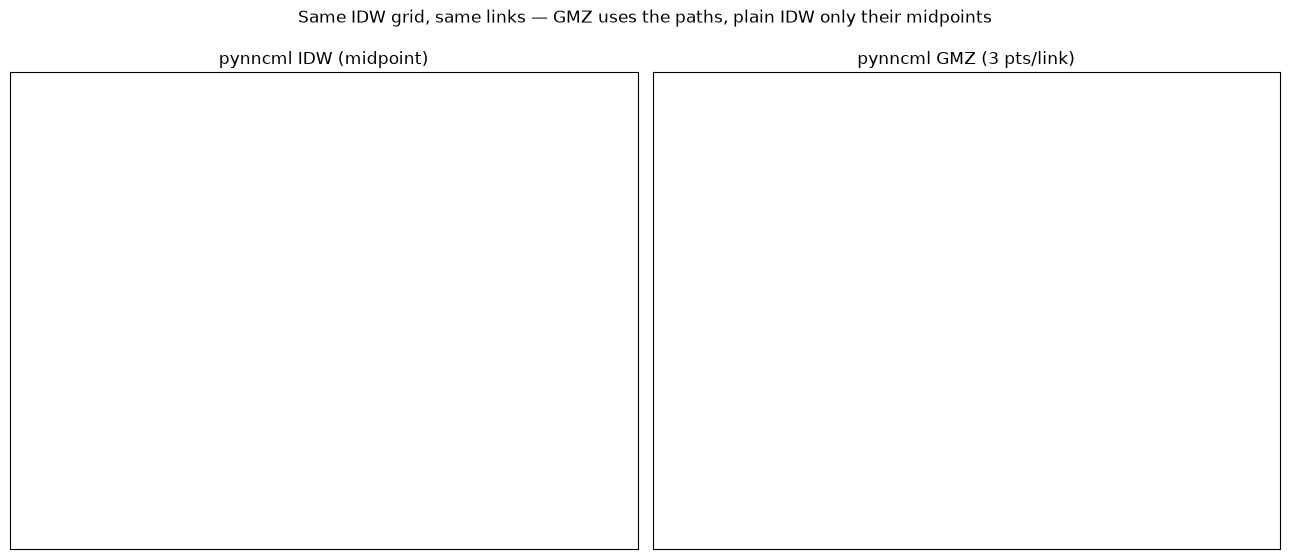

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

x0, y0 = np.asarray(cml.site_0_x), np.asarray(cml.site_0_y)
x1, y1 = np.asarray(cml.site_1_x), np.asarray(cml.site_1_y)

for ax, name in zip(axes, ["pynncml_idw", "pynncml_gmz"]):
    m = maps[name]
    extent = [np.min(m["x"]), np.max(m["x"]), np.min(m["y"]), np.max(m["y"])]
    ax.imshow(m["grid"], origin="lower", extent=extent, vmin=0, vmax=vmax,
              cmap="turbo", aspect="auto", interpolation="nearest")
    for a, b, c, d in zip(x0, y0, x1, y1):
        ax.plot([a, c], [b, d], color="white", lw=0.5, alpha=0.5)
    ax.set_title(m["label"])
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Same IDW grid, same links — GMZ uses the paths, plain IDW "
             "only their midpoints", y=0.99, fontsize=12)
plt.tight_layout()

## How much do they actually differ?

Comparing on a common footing: each map resampled to its own domain mean and
peak. A large spread in the peak with a similar mean means the methods
disagree about *where* the rain is, not how much.

In [7]:
print(f"{'method':20s} {'mean':>8} {'p99':>8} {'max':>8}   (mm/h)")
for name, m in maps.items():
    g = m["grid"][np.isfinite(m["grid"])]
    print(f"{name:20s} {g.mean():8.3f} {np.percentile(g, 99):8.2f} "
          f"{g.max():8.2f}")

wet = R[np.isfinite(R) & (R >= 0.1)]
print(f"\nlink observations    {wet.mean():8.3f} "
      f"{np.percentile(wet, 99):8.2f} {wet.max():8.2f}")
print("\n(link stats are over wet links only, so the mean is "
      "not comparable to a\n grid mean that includes dry area)")

method                   mean      p99      max   (mm/h)
pycomlink_idw           2.632    34.55    85.92
pynncml_idw             1.299    34.15    84.62
pynncml_gmz             1.682    42.79    66.61
mergeplg_idw            2.130    33.01    72.85
mergeplg_kriging        2.186    30.29    80.52

link observations       8.539    77.93   107.72

(link stats are over wet links only, so the mean is not comparable to a
 grid mean that includes dry area)


## Where to go next

- `projects/opensense_pipeline/` — these interpolators against radar, with
  merging (`MergeDifferenceIDW`, `MergeKrigingExternalDrift`) and a
  synthetic-truth benchmark that ranks them.
- `projects/rainfall_field_sim/` — the same reconstruction problem where the
  true field is known, which is how you find out that IDW keeps only ~13–17%
  of convective peak intensity.
- `notebooks/model_driven_tutorial.ipynb` — the full PyNNcml chain, from raw
  attenuation to these maps.
